Saving Cleaned data.csv to Cleaned data (1).csv


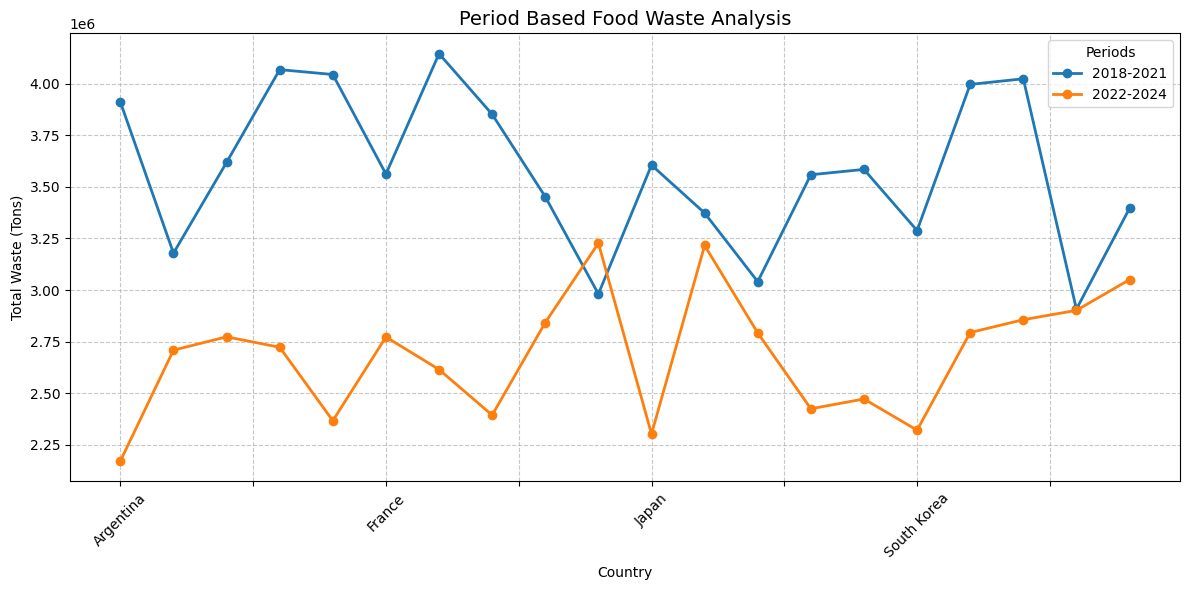

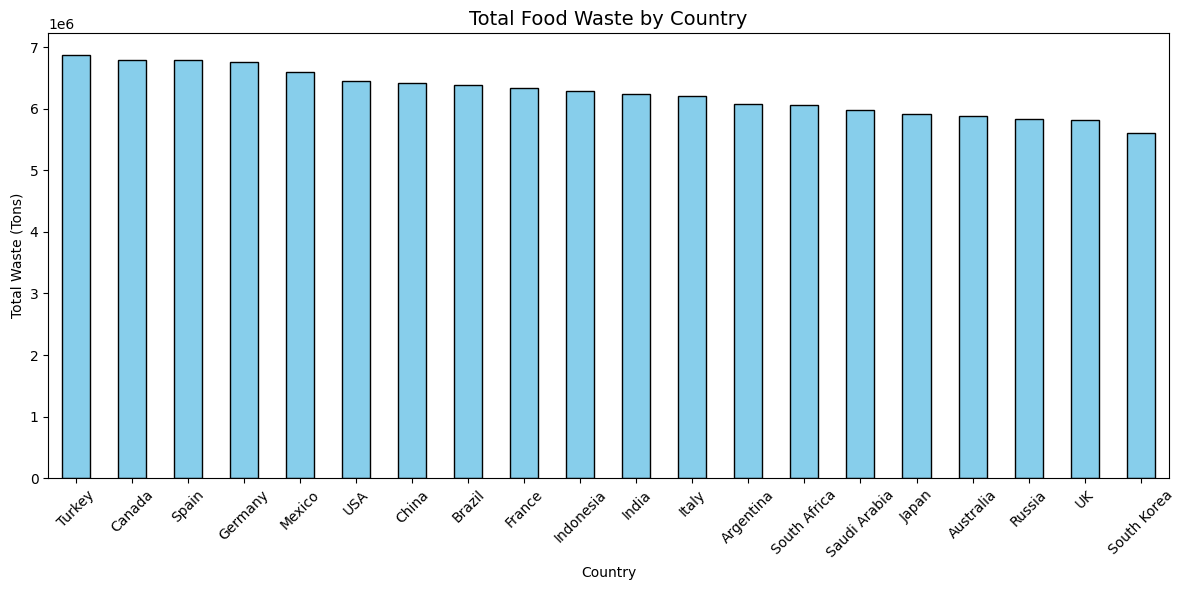

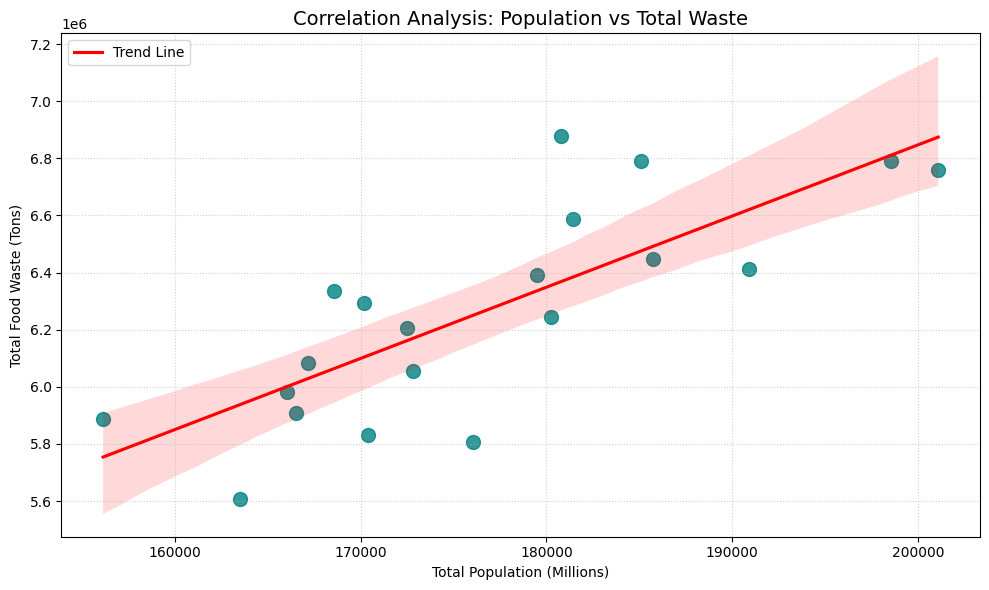

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Data
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('Cleaned data.csv')
# 2. Data Preparation for Charts

# Data for Chart 1: Period Based Food Chart (Line Chart)
# We sum the waste for each Country and Year Category
period_data = df.groupby(['Country', 'Year Category'])['Sum of Total Waste (Tons)'].sum().unstack()

# Data for Chart 2: Country Based Waste Chart (Bar Chart)
# We sum the total waste per country and sort it
country_data = df.groupby('Country')['Sum of Total Waste (Tons)'].sum().sort_values(ascending=False)

# Data for Chart 3: Correlation Analysis
# We sum Population and Waste per country to see the relationship
corr_data = df.groupby('Country').agg({
    'Sum of Population (Million)': 'sum',
    'Sum of Total Waste (Tons)': 'sum'
}).reset_index()

# ---------------------------------------------------------
# CHART 1: Period Based Food Chart (Line Chart)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
period_data.plot(kind='line', marker='o', ax=plt.gca(), linewidth=2)
plt.title('Period Based Food Waste Analysis', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Total Waste (Tons)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Periods')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# CHART 2: Country Based Waste Chart (Clustered Column)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
country_data.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Food Waste by Country', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Total Waste (Tons)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# CHART 3: Correlation Analysis (Scatter Plot with Trend Line)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.regplot(data=corr_data, x='Sum of Population (Million)', y='Sum of Total Waste (Tons)',
            scatter_kws={'color':'teal', 's':100}, line_kws={'color':'red', 'label':'Trend Line'})
plt.title('Correlation Analysis: Population vs Total Waste', fontsize=14)
plt.xlabel('Total Population (Millions)')
plt.ylabel('Total Food Waste (Tons)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [13]:
top_5_countries = df.groupby('Country')['Sum of Total Waste (Tons)'].sum().sort_values(ascending=False).head(5)
print(" Top 5 Countries with the Highest Levels of Food Waste ")
print(top_5_countries)

top_5_categories = df.groupby('Food Category')['Sum of Total Waste (Tons)'].sum().sort_values(ascending=False).head(5)
print("\n The Top 5 Food Categories with the Most Waste")
print(top_5_categories)

 Top 5 Countries with the Highest Levels of Food Waste 
Country
Turkey     6879885.81
Canada     6790678.49
Spain      6790574.25
Germany    6760053.01
Mexico     6589169.52
Name: Sum of Total Waste (Tons), dtype: float64

 The Top 5 Food Categories with the Most Waste
Food Category
Prepared Food          17929317.92
Beverages              16354455.29
Bakery Items           15587955.51
Fruits & Vegetables    15522081.20
Meat & Seafood         15371347.52
Name: Sum of Total Waste (Tons), dtype: float64
